In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def plot_paretto(pysr_model,x_data, dx_data, dx_func, dx_string):
    dx_pred_true = dx_func(x_data.x, x_data.y)

    loss_true = np.mean((dx_data - dx_pred_true)**2)
    
    import sympy as sp
    from pysr.export_sympy import pysr2sympy
    
    # Convert string to sympy (same parser PySR uses)
    expr = pysr2sympy(dx_string)
    
    # Count nodes (PySR-like complexity proxy)
    complexity_true = sum(1 for _ in sp.preorder_traversal(expr))

    df = pysr_model.equations_

    print(df)
    
    # Extract relevant columns
    complexity = df["complexity"]
    loss = df["loss"]
    
    # Best model (PySR-selected)
    best_idx = pysr_model.get_best()
    print(best_idx)
    best_complexity = best_idx.complexity
    best_loss = best_idx.loss
    
    # Plot Pareto front
    plt.figure(figsize=(7, 5))
    plt.scatter(complexity, loss, label="Candidate models")
    
    # Highlight best model
    plt.scatter(best_complexity, best_loss, color="red", s=100, label="Best model")
    plt.scatter(complexity_true, loss_true, color="green", s=100, label="True model")
    
    # Optional: connect Pareto front (sorted by complexity)
    sorted_idx = complexity.argsort()
    plt.plot(complexity.iloc[sorted_idx], loss.iloc[sorted_idx], alpha=0.5)
    
    plt.xlabel("Complexity")
    plt.ylabel("Loss")
    plt.title("Pareto Front (PySR)")
    plt.legend()
    plt.grid(True)
    
    plt.show()
    

/home/oriolca/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-07-09 16:32:16,086 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-07-09 16:32:16,104 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2026-07-09 16:32:16,105 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



datasets/bact_res_SNR_20_0.csv 2026-03-23 15:24:16.396867
238.603772080521
{'_a0_': 19.728911295397495, '_a1_': 0.5144319555824509}
{'_a0_': 9.8082975367452, '_a1_': 0.5115284516407089}


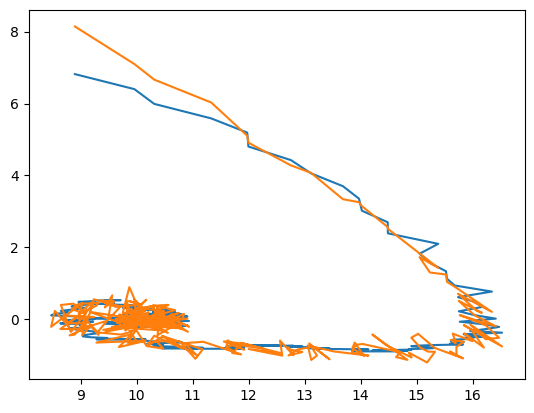

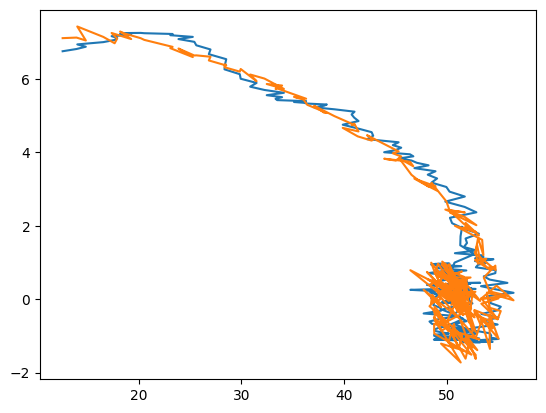

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
    complexity      loss                                           equation  \
0            1  1.212667                                         0.01649312   
1            3  1.071361                                      15.331179 / y   
2            4  0.333644                                cube(25.864353 / y)   
3            5  0.277979                         (105.51967 / y) - 2.386431   
4            6  0.145804              cube(y + -41.840782) * -0.00028635736   
5            7  0.050562                 (x * -0.2563262) + (127.70456 / y)   
6            9  0.013245           (((y * -1.8979614) / x) - x) + 19.675467   
7           11  0.011271  ((x * -0.9571298) + ((y * -1.8323007) / x)) + ...   
8           12  0.010883  ((x + (sin(1.934206 / x) * y)) * -0.95225465) ...   
9           13  0.009153  ((y * ((-1.5915124 / x) + -0.020865574)) + (x ...   
10          14  0

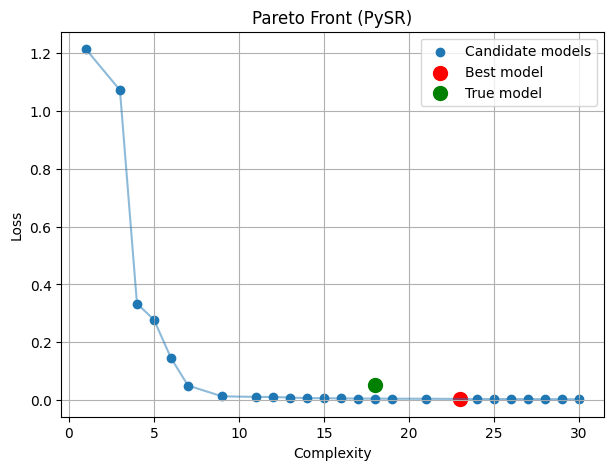

    complexity      loss                                           equation  \
0            1  6.088661                                          1.2950352   
1            3  1.404067                                       x - 9.950782   
2            5  1.348078                      (y * -0.23918541) + 12.625235   
3            6  0.440794                       (square(x) / y) + -1.8984226   
4            7  0.130351                  ((y * -1.9185545) / x) + 9.799156   
5            8  0.130054               (y * sin(-1.9364245 / x)) + 9.828388   
6            9  0.129891           (sin(sin(-1.9547397 / x)) * y) + 9.85768   
7           10  0.125913       ((sin(x) + (y * -1.9085919)) / x) + 9.778654   
8           11  0.123164  ((y - cube(sin(x))) * (-1.9049048 / x)) + 9.76481   
9           12  0.110072  ((y + cos(x * 13.634509)) * (-1.9305004 / x)) ...   
10          13  0.109396  (((cos(cube(x + -12.91633)) + y) / x) * -1.929...   
11          14  0.107685  (((y - cos((x * 5.5611396)

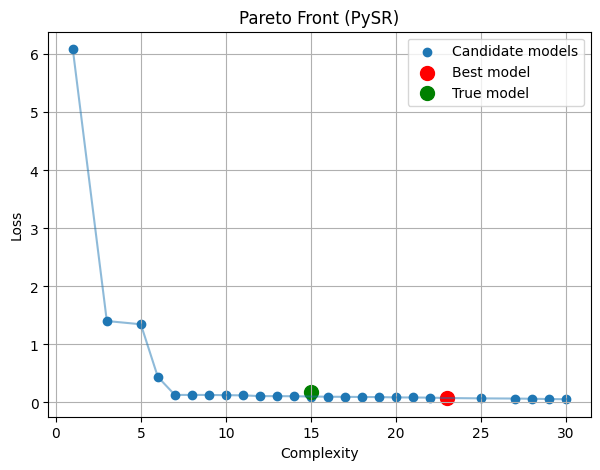

In [2]:
# Import Machine Scientist
from importlib.machinery import SourceFileLoader
import sys
from pathlib import Path
from copy import deepcopy
import pynumdiff
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "../rguimera-machine-scientist/mcmc.py"
path = os.path.join(script_dir, relative_module_path)
mcmc = SourceFileLoader("mcmc", path).load_module()

#Import prior
path = os.path.join(script_dir, "../rguimera-machine-scientist/Prior/")
sys.path.append(path)
from fit_prior import read_prior_par
prior = read_prior_par('../rguimera-machine-scientist/Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat')

files = [str(f) for f in Path("datasets").glob("bact_res_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '(_a0_ + ((-1 * x) + (((-1 * x) * y) / (1 + (_a1_ * pow2(x))))))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='(_a0_ + (((-1 * y) * x) / (1 + (_a1_ * pow2(x)))))'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/bact_res_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return 20. - x - x *y/(1+0.5 * x*x)
dx_string = "20. - x0 - x0 *x1/(1+0.5 * x0*x0)"
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/bact_res_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return 10.- x *y/(1+0.5 * x*x)
dy_string = "10. - x0 *x1/(1+0.5 * x0*x0)"
plot_paretto(mx,data, dydt_hat, dy, dy_string)

datasets/bar_mag_SNR_20_0.csv 2026-03-23 15:24:17.139867
-534.240926502865
{'_a0_': 0.5108021012361889}
{'_a0_': -0.49170946801667875}


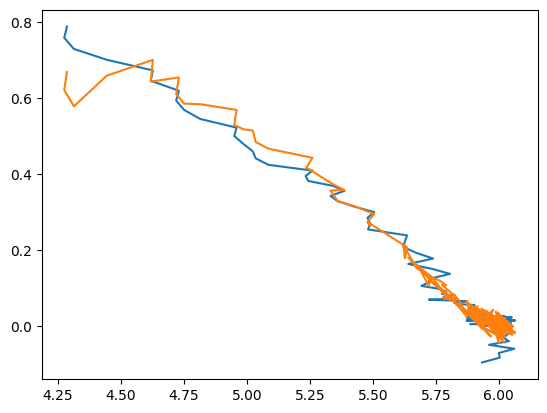

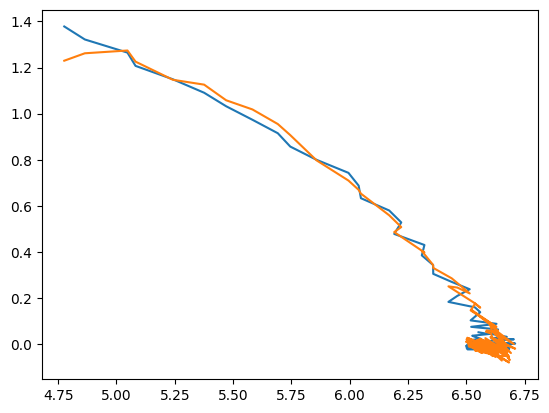

    complexity      loss                                           equation  \
0            1  0.037438                                        0.116579585   
1            3  0.022062                                     square(sin(y))   
2            4  0.000514                                sin(x * 0.52437633)   
3            6  0.000447                 cos((x * -0.50549054) + 358984.97)   
4            8  0.000395  cos(-1.0902907 * (-358669.84 + (x * 0.46846366)))   
5           10  0.000383       sin(sin(x) * -1.9133887) * sin(x * 0.522099)   
6           11  0.000371  sin(x * 0.52254283) * sin(exp(sin(x) + 1.25343...   
7           12  0.000307  sin(((sin(sin(x) * -11.067386) * -0.055466052)...   
8           13  0.000306  sin((x + (sin(sin(sin(x) * -11.076744)) * -0.0...   
9           14  0.000283  sin((x * 0.52344847) + (sin((sin(x) * -11.5024...   
10          16  0.000280  sin(((sin((sin(x) * -11.50241) + -8.1100405e6)...   
11          19  0.000234  sin((x + (sin(sin(x) * -11

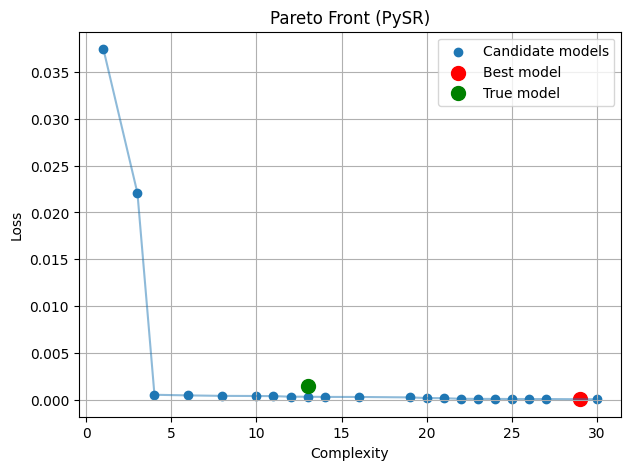

    complexity      loss                                           equation  \
0            1  0.096144                                          0.1199059   
1            3  0.006802                                      6.5940104 - y   
2            4  0.001064                                 0.9298267 - cos(x)   
3            6  0.001022                   0.94400907 - cos(x / 0.99412286)   
4            7  0.000261               square(cos(x * -0.7931)) * 1.4439733   
5            8  0.000128      (cos(x * 1.5833906) * 0.7264801) + 0.71348894   
6            9  0.000115  (0.99569386 - cos(cos(x * -0.79425037))) * 3.1...   
7           11  0.000115  (0.9951513 - cos(cos(x * 0.79455805) * 1.06143...   
8           12  0.000114  (square(sin(cos(x * 0.8318746)) + -0.226757) -...   
9           13  0.000110  (cos(((cos(y) * 0.038112685) + -1.6248916) * x...   
10          14  0.000100  ((-1.9044038e-6 / (y + -6.5583625)) + (cos(x *...   
11          15  0.000088  ((0.00029508944 / (y + -6.

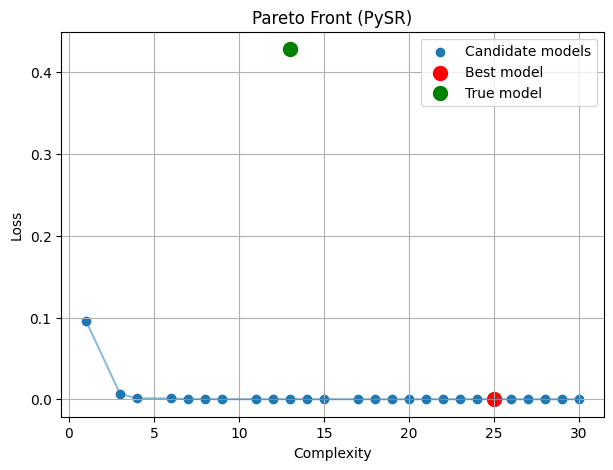

In [3]:
files = [str(f) for f in Path("datasets").glob("bar_mag_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '((_a0_ * sin((x - y))) - sin(x))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='((_a0_ * sin((x - y))) - sin(y))'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/bar_mag_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return ((0.5 * np.sin((x - y))) - np.sin(x))
dx_string = "0.5 * sin(x0 - x1) - sin(x0)"
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/bar_mag_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return ((0.5 * np.sin((x - y))) - np.sin(y))
dy_string = "0.5 * sin(x0 - x1) - sin(x1)"
plot_paretto(mx,data, dydt_hat, dy, dy_string)

datasets/glider_SNR_20_0.csv 2026-03-23 15:24:17.926867
757.872614434140
{'_a0_': -0.04093129581332233}
{}


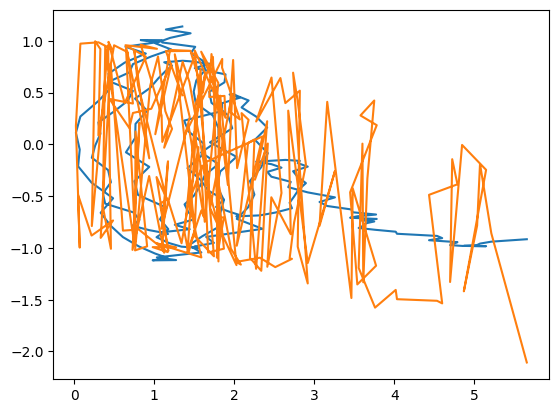

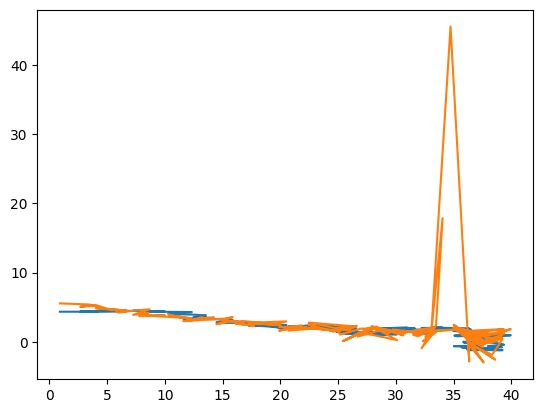

    complexity      loss                                           equation  \
0            1  0.402095                                        -0.20025717   
1            3  0.344379                                     x * -0.1405311   
2            4  0.220407                               -0.23206572 - sin(y)   
3            5  0.186704                           sin(-63529.613 - sin(y))   
4            6  0.163390                        (y * -0.026394926) * sin(y)   
5            7  0.106066                    sin((x * -0.24633896) - sin(y))   
6            8  0.075809                sin((sin(x) + -208100.02) - sin(y))   
7            9  0.060661           ((y * sin(y)) + square(x)) * -0.02877391   
8           10  0.056517     (square(x) + (y * sin(sin(y)))) * -0.032067955   
9           11  0.043464  ((sin(y) * (y + -9.52285)) + square(x)) * -0.0...   
10          12  0.041904  sin((square(x) + ((y + -10.917404) * sin(y))) ...   
11          13  0.030233  (cos(-9.242523 / (-1.98410

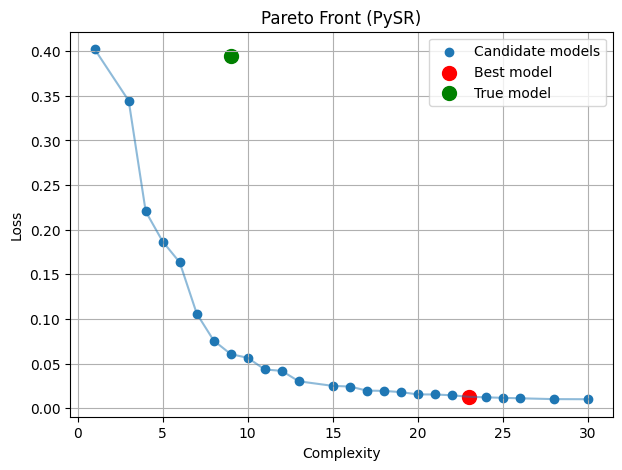

    complexity      loss                                           equation  \
0            1  0.613696                                                  x   
1            3  0.593052                                      x - 0.1436811   
2            4  0.409093                                         x - cos(y)   
3            5  0.374363                                    x - sin(cos(y))   
4            6  0.360695                               x - sin(sin(cos(y)))   
5            7  0.282753                              x - (sin(cos(y)) / x)   
6            8  0.201911                    x - (cos(y) / (x + 0.21792538))   
7            9  0.193783               x - ((cos(y) / 0.37761414) / exp(x))   
8           10  0.184294           x - ((sin(cos(y)) * 3.0466216) / exp(x))   
9           11  0.152342  x - (sin(0.45303825 / (cos(y) - 0.20265187)) / x)   
10          12  0.144277  x - (sin(sin(0.48389423 / (cos(y) - 0.19179724...   
11          13  0.139638  x - (sin(sin(0.42024323 / 

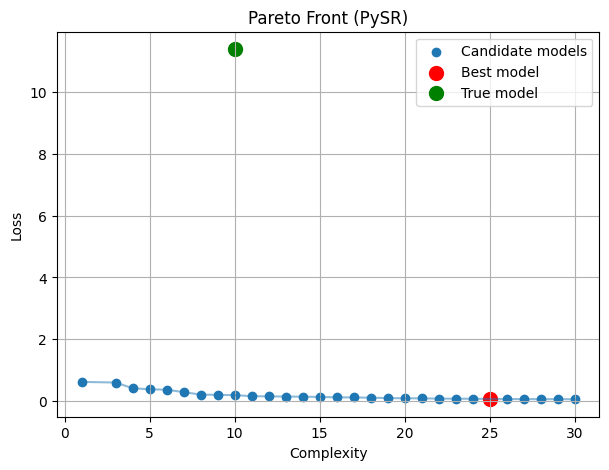

In [4]:
files = [str(f) for f in Path("datasets").glob("glider_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '((_a0_ * pow2(x)) - sin(y))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='(x - (cos(y) / x))'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/glider_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return -0.05*x*x - np.sin(y)
dx_string = "-0.05*x0*x0 - sin(x1)"
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/glider_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return (x - (np.cos(y) / x))
dy_string = "x - cos(y) / x"
plot_paretto(mx,data, dydt_hat, dy, dy_string)

datasets/lotka_volterra_SNR_20_0.csv 2026-03-23 15:24:18.615867
-28.7376816973282
{'_a0_': -2.705289486141788, '_a1_': 0.872164983547678}
{'_a0_': 1.8811308043423063}


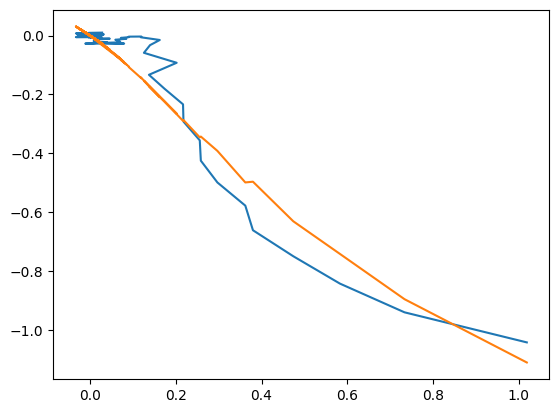

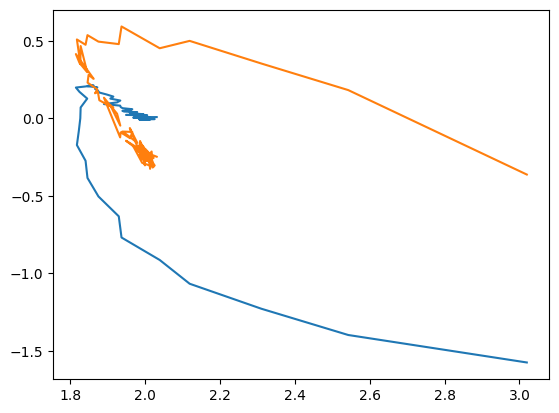

    complexity      loss                                           equation  \
0            1  0.042060                                        -0.07571265   
1            3  0.002349                                    x / -0.77482045   
2            4  0.002156                                 1.0116446 - exp(x)   
3            5  0.001940                            1.0069274 - exp(sin(x))   
4            6  0.000921                     cube(cube(cos(x))) + -1.007291   
5            7  0.000659          square(cube(square(cos(x)))) + -0.9962302   
6            8  0.000396            (-0.66814035 - sin(0.46378046 / x)) * x   
7            9  0.000236      x * (sin(sin(-0.46548575 / x)) + -0.72371596)   
8           10  0.000202  (-0.70030445 - sin(sin(0.46361017 / sin(x)))) * x   
9           11  0.000098  x * (sin(sin(-0.6364812 / (x + 0.054424934))) ...   
10          12  0.000082  (-0.71220875 - sin(sin(sin(0.08038053 / x) / 0...   
11          13  0.000051  (-0.7550327 - sin(sin(sin(

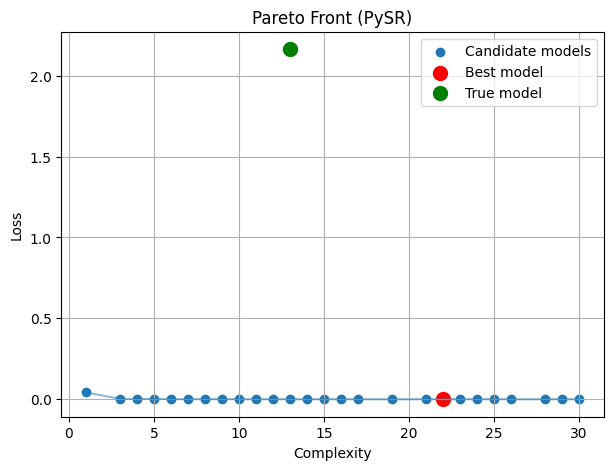

    complexity      loss                                           equation  \
0            1  0.096002                                        -0.05578286   
1            3  0.022539                                     x * -1.6753948   
2            4  0.013366                             square(x) * -2.9334755   
3            5  0.011368                       square(sin(x)) / -0.28503633   
4            6  0.008977                           cube((y + -4.12154) * x)   
5            7  0.007023                  cube((x * -9.819695) / square(y))   
6            8  0.002361              x * (cos(0.24474639 / x) * -2.193829)   
7            9  0.001939        (sin(cos(0.24597116 / x)) * -2.5315914) * x   
8           10  0.000871  sin(-0.9914985 / (x - -0.15091646)) * (x * 2.1...   
9           11  0.000544  (x * 2.5072582) * sin(sin(-0.9959268 / (x - -0...   
10          12  0.000203  cos(15.216841 / ((y / 1.4608107) - x)) * (x * ...   
11          13  0.000110  sin(sin(11.829758 / (x - (

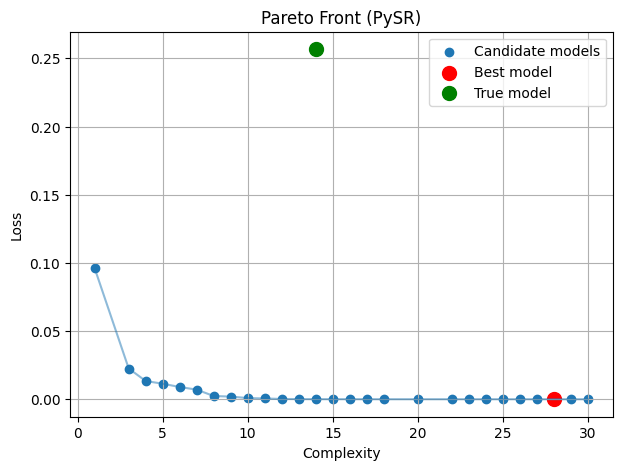

In [5]:
files = [str(f) for f in Path("datasets").glob("lotka_volterra_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '((_a0_ * x) + ((_a1_ * (x * y)) - pow2(x)))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='((_a0_ * y) + -((x * y) + pow2(y)))'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/lotka_volterra_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return ((3. * x) + ((2. * (x * y)) - x* x))
dx_string = "3. * x0 + 2. * x0 * x1 - x0 * x0"
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/lotka_volterra_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return ((2. * y) + -((x * y) + y*y))
dy_string = "2. * y -x * y - x1 * x1"
plot_paretto(mx,data, dydt_hat, dy, dy_string)

datasets/pred_prey_SNR_20_0.csv 2026-03-23 15:24:19.293867
690.581154731920
{'_a0_': 0.09768281934886258}
{'_a0_': 0.24572077273026338}


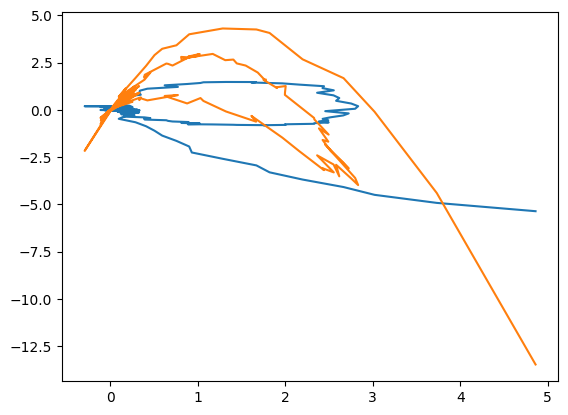

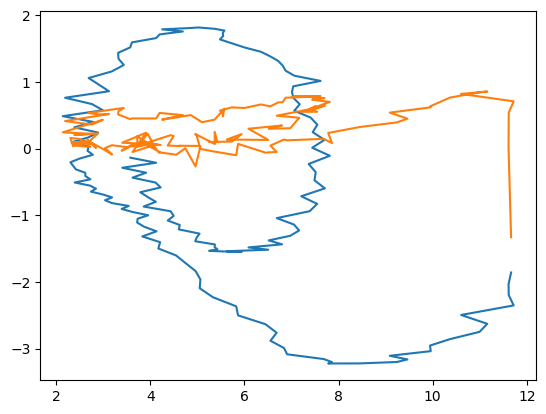

    complexity      loss                                           equation  \
0            1  1.228358                                         -0.2601683   
1            3  0.918826                                     y * -0.1042739   
2            4  0.329844                              cube(y) * -0.00231179   
3            5  0.245902                  square(square(y)) * -0.0002358059   
4            6  0.157280             (cube(y) * -0.0030484647) + 0.52027774   
5            7  0.123391                 x * ((10.677788 / y) + -2.1632123)   
6            8  0.078832             (y + -5.625514) * sin(x * -0.33899662)   
7            9  0.025006   (5.5517926 - y) / ((1.1686003 / x) + 0.98743635)   
8           11  0.024024  ((5.6491547 - y) / ((1.1411363 / x) + 0.994868...   
9           12  0.013909  ((sin(x) - y) + 4.856988) / ((0.8378205 / x) +...   
10          13  0.012604  ((sin(x) - y) + 4.8759065) / square((0.2649658...   
11          14  0.011943  ((sin(x) - y) + 4.8691735)

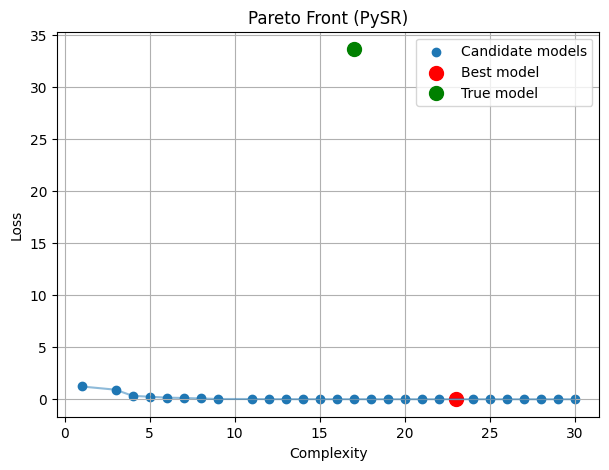

    complexity      loss                                           equation  \
0            1  2.004202                                        -0.57162064   
1            3  1.500136                                     x + -1.4461911   
2            4  1.308740                                 cos(x) * -1.190143   
3            5  0.550965                              (y * -0.29594812) + x   
4            6  0.325504                        x - square(y * -0.19838046)   
5            8  0.266285           (x - square(y * 0.18837084)) * 1.2654201   
6            9  0.213742              ((y * -0.55304813) + x) + exp(sin(x))   
7           10  0.190315        x - (square(y * -0.16807947) / cos(cos(x)))   
8           11  0.038776   y * ((y * -0.082206994) + (x / (x + 0.8328444)))   
9           12  0.031489  sin((y * -0.08406533) + (x / (x + 0.78068364))...   
10          13  0.026724  y * sin(sin((x / (x + 0.7419392)) + (y * -0.08...   
11          14  0.024303  y * sin(sin(sin((x / (x + 

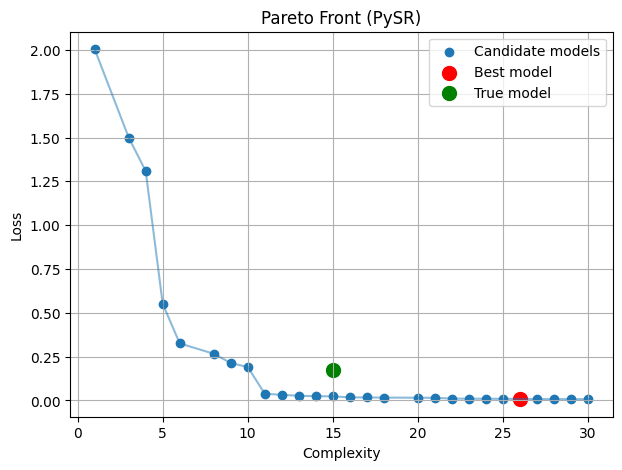

In [6]:
files = [str(f) for f in Path("datasets").glob("pred_prey_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '(x * (_a0_ - (x - (y / (1 + x)))))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='(x * ((y / (1 + y)) - (_a0_ * x)))'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/pred_prey_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return (x * (4. - (x - (y / (1. + x)))))
dx_string = '(x0 * (4 - (x0 - (x1 / (1 + x0)))))'
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/pred_prey_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return y * ((x / (1 + x)) - (0.075 * y))
dy_string = "(x1 * ((x0 / (1 + x1)) - (0.075 * x1)))"
plot_paretto(mx,data, dydt_hat, dy, dy_string)

datasets/sh_flow_SNR_20_0.csv 2026-03-23 15:24:20.024867
-160.683318343616
{}
{'_a0_': 0.09955265662881504}


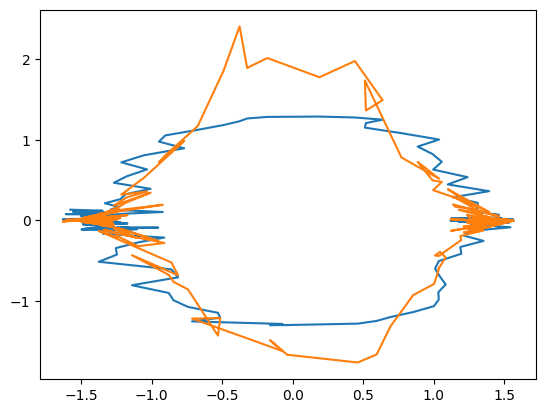

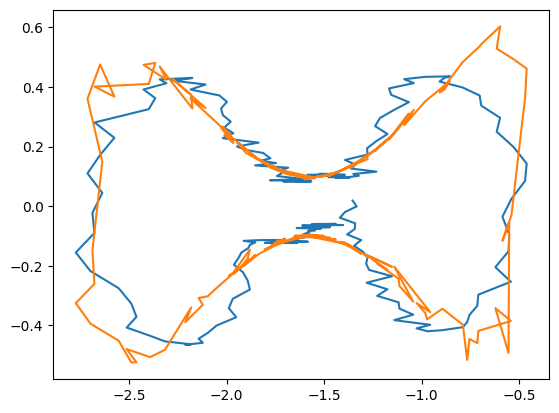

    complexity      loss                                           equation  \
0            1  0.259472                                      0.00017647813   
1            3  0.039170                                     -1.5765221 - y   
2            4  0.015375                               cube(-1.5894119 - y)   
3            5  0.002861                          cube(cos(y) * -1.2598017)   
4            6  0.002423                     sin(cube(cos(y))) * -2.1123831   
5            7  0.002268                sin(sin(cube(cos(y)))) * -2.2142851   
6            8  0.002246         1.5502099 * sin(cube(cos(y) * -1.1310029))   
7            9  0.002117     sin(sin(sin(cube(-1.5744654 - y)))) * 1.756643   
8           10  0.001937   cos(y) * (sin(sin(y) * -3.2110703) * -1.4339143)   
9           11  0.001871  (sin(exp(sin(y) * -1.1780394)) * cos(y)) * -1....   
10          12  0.001721  cube(cos(y - (sin(y * 6.245258) * -0.045174997...   
11          14  0.001707  (cube(cos((sin(y * 6.23956

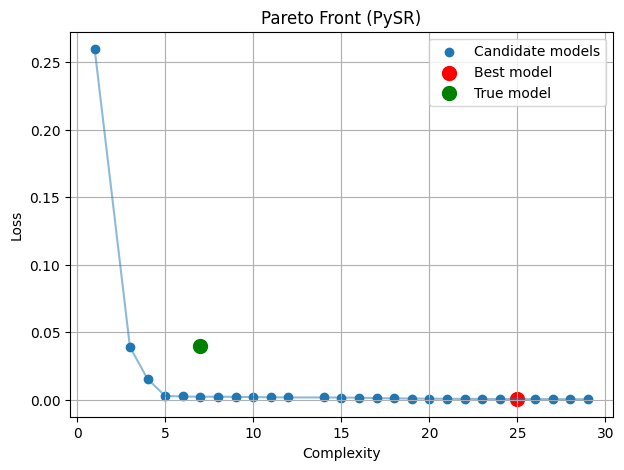

    complexity      loss                                           equation  \
0            1  0.057977                                        0.004199013   
1            3  0.021552                                     x * 0.15553676   
2            4  0.018871                                sin(x) * 0.21745558   
3            5  0.009176                                 x * square(cos(y))   
4            6  0.004143                              cos(x) * sin(cube(x))   
5            7  0.004061                       cos(-802035.56 - sin(y)) * x   
6            8  0.001537              x * (cos(cube(sin(y))) + -0.49622083)   
7            9  0.000948         sin(x / (sin(y) + 1.4581772)) * 0.42858088   
8           11  0.000879  sin(x / (-0.45760015 / square(cos(cos(y))))) *...   
9           12  0.000724  (x - sin(x / (square(sin(y)) + -1.2862222))) *...   
10          13  0.000627  sin(x) * (cos(cube(sin(x * cube(sin(y))))) + -...   
11          15  0.000604  sin(x + -31.442698) * (cos

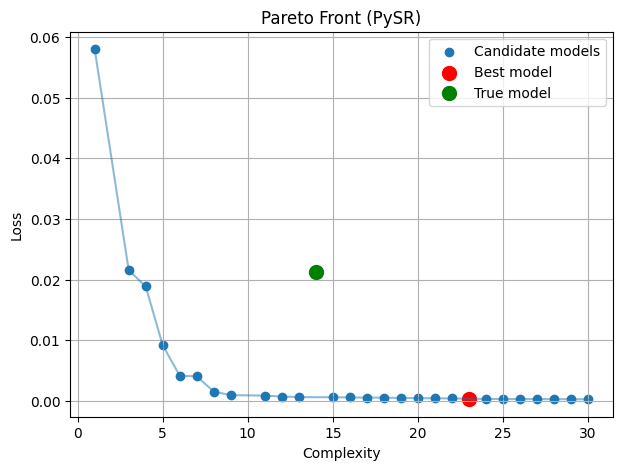

In [7]:
files = [str(f) for f in Path("datasets").glob("sh_flow_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '(cos(x) / tan(y))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='(sin(x) * (pow2(cos(y)) + (_a0_ * pow2(sin(y)))))'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/sh_flow_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return (np.cos(x) / np.tan(y))
dx_string = '(cos(x) / tan(y))'
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/sh_flow_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return (np.sin(x) * (np.cos(y)**2.) + (0.1 * np.sin(y)**2.))
dy_string = "(sin(x0) * (cos(x1)**2.) + (0.1 * sin(x1)**2.))"
plot_paretto(mx,data, dydt_hat, dy, dy_string)

datasets/vd_pol_SNR_20_0.csv 2026-03-23 15:24:20.710867
-318.463368449678
{'_a0_': 5.3627511857132655, '_a1_': 0.0569109730782952}
{'_a0_': -0.09987114307028859}


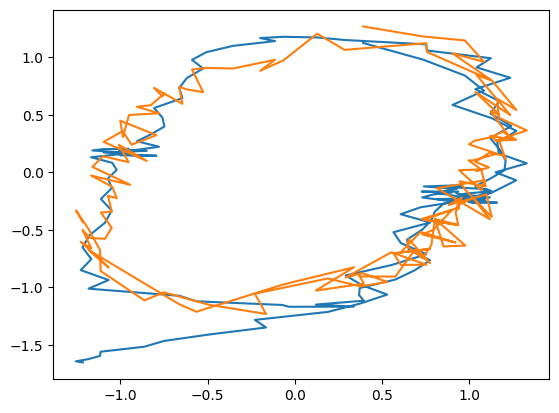

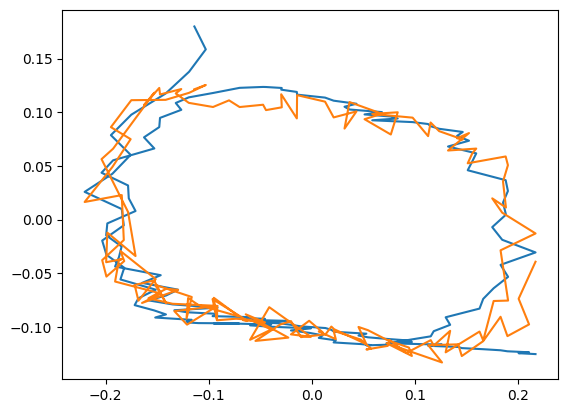

    complexity      loss                                           equation  \
0            1  0.354952                                                  y   
1            3  0.090342                                     y / 0.20067899   
2            4  0.079027                               cube(y / 0.17933206)   
3            5  0.069403                           cube(sin(y / 0.1306782))   
4            6  0.059580                           cube((5.632445 - x) * y)   
5            7  0.041409                     cube((5.645135 - cube(x)) * y)   
6            8  0.041059                cube((5.676763 - cube(x)) * sin(y))   
7            9  0.033609      cube(y / (cube(x * 0.29921424) + 0.17849573))   
8           10  0.033170  cube(y / (cube(sin(x * 0.30994958)) + 0.1786374))   
9           11  0.031462   cube(y / (cube(x * 0.3104854) + 0.19084746)) + y   
10          12  0.030572  y + cube(y / square(cube(x * 0.34286523) + 0.4...   
11          13  0.029655  (cube(y) + cube(y / (y + (

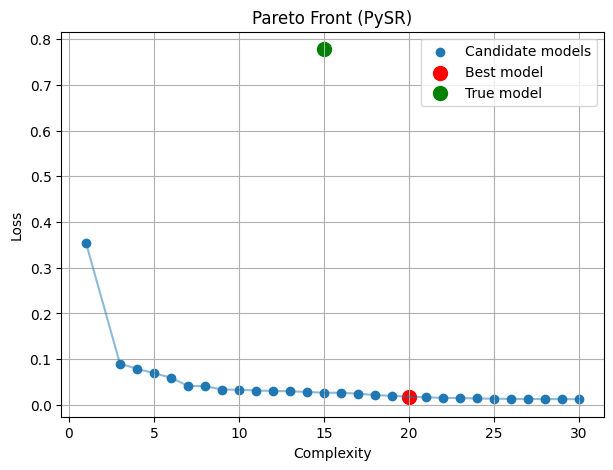

    complexity      loss                                           equation  \
0            1  0.008026                                       -0.023268422   
1            3  0.000109                                    x * -0.10221922   
2            4  0.000109                               sin(x * -0.10241328)   
3            5  0.000109                  (x - -0.0017334662) * -0.10217349   
4            6  0.000097                  exp(x * -0.10226606) + -1.0043557   
5            7  0.000095          (15.238651 / (x + 12.237242)) - 1.2521735   
6            8  0.000089           (x * -0.10138961) - cube(y + 0.03931742)   
7            9  0.000075    x * (cube(cube(y / -0.29863334)) + -0.10161362)   
8           10  0.000064  (x * -0.10129336) - (exp(y * 47.640842) * 1.49...   
9           11  0.000063  x * ((cube(cube(y / -0.2829434)) * x) + -0.100...   
10          12  0.000061  ((x * (exp(y * 50.738773) * -1.6310918e-6)) + ...   
11          13  0.000056  exp(x * -0.10174706) + (-1

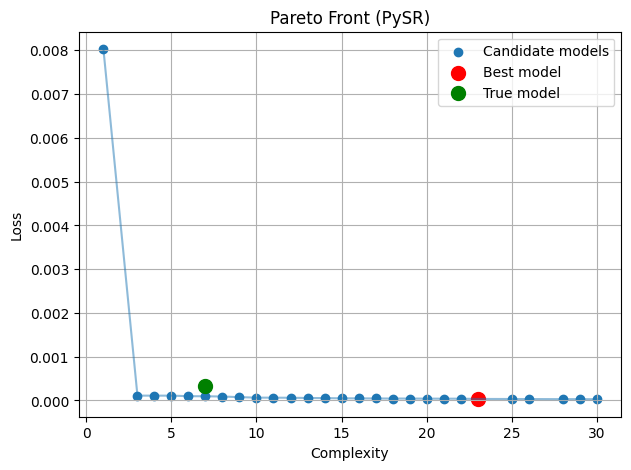

In [8]:
files = [str(f) for f in Path("datasets").glob("vd_pol_SNR_20_0.csv")]
for file in files:
    print(file, datetime.fromtimestamp(os.path.getmtime(file)))
    try:
        with open(f'models/{os.path.basename(file)[:-4]}_BMS_SMOOTH.pkl', "rb") as f:
            m = pickle.load( f)
        print('###############################################')
        print(file)
        print(m)
        print(m['x'].E)
    except:
        pass
    #with open(file, "r") as f:
    #    data = pd.read_csv(f)
    data=pd.read_csv(file)

    x={}
    y={}
    dx = {}
    
    dy = {}
    
    x['d0']=deepcopy(data)
    y['d0']=deepcopy(data)
    y['d0'].x=deepcopy(x['d0'].y)
    y['d0'].y=deepcopy(x['d0'].x)
    
    h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]
    
    par = [2, 41, 41]
    x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].x, h, par, options=None)
    y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
            x['d0'].y, h, par, options=None)
    pms_x = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dxdt_hat),
        prior_par=prior,
        from_string = '(_a0_ * (y + (_a1_ * (x - pow3(x)))))'
    )
    pms_y = mcmc.Tree(
        variables=['x','y'],
        parameters=["a%d" % i for i in range(5)],
        x=data,
        y=pd.Series(dydt_hat),
        prior_par=prior,
        from_string ='(x * _a0_)'
    )
    print(pms_x.E+pms_y.E)
    print(pms_x.par_values['d0'])
    print(pms_y.par_values['d0'])
    
    pred_x = pms_x.predict(pms_x.x)
    pred_y = pms_y.predict(pms_y.x)
    
    plt.plot(pms_x.x['d0']['x'],dxdt_hat)
    plt.plot(pms_x.x['d0']['x'],pred_x['d0'])
    
    plt.show()
    
    plt.plot(pms_x.x['d0']['y'],dydt_hat)
    plt.plot(pms_x.x['d0']['y'],pred_y['d0'])

    data = pms_x.x['d0']
    plt.show()


with open(f'models/vd_pol_SNR_20_0_PYSR_x.pkl', "rb") as f:
    mx = pickle.load( f)
def dx(x,y):
    return (10. * (y + (x - x**3.)/3.))
dx_string = '(10. * (x1 + (x0 - x0**3.)/3.))'
plot_paretto(mx,data, dxdt_hat, dx, dx_string)


with open(f'models/vd_pol_SNR_20_0_PYSR_y.pkl', "rb") as f:
    mx = pickle.load( f)
def dy(x,y):
    return -x/10. 
dy_string = "-x0/10."
plot_paretto(mx,data, dydt_hat, dy, dy_string)